In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded= files.upload()

In [ ]:
df= pd.read_csv("FinalCropStressDataset.csv")

In [ ]:
df.head()

,cloud_coverage,Date,day,mean_ndvi,month,year,Region,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,Season_Type,14_dayRainSum,Heatwave,Coldwave,rainfall_anomaly
0,0.000000,2022-01-01,1,0.061829,1,2022,Haryana,18.1,4.2,0.0,79,0.39,0.39,Rabi,0.0,0,0,0.0
1,0.349554,2022-01-02,1,0.061829,2,2022,Haryana,20.5,7.2,0.0,86,0.45,0.45,Rabi,0.0,0,0,0.0
2,0.000000,2022-01-03,1,0.089505,3,2022,Haryana,23.8,9.9,0.0,69,0.41,0.40,Rabi,0.0,0,0,0.0
3,0.000000,2022-01-04,1,0.117181,4,2022,Haryana,36.0,20.6,0.0,27,0.36,0.36,Rabi,0.0,0,0,0.0
4,0.000000,2022-01-05,1,0.144858,5,2022,Haryana,42.5,25.8,0.0,29,0.35,0.34,Off-season,0.0,0,0,0.0


In [ ]:
df.columns

Index(['cloud_coverage', 'Date', 'day', 'mean_ndvi', 'month', 'year', 'Region',
       'Temp_Max', 'Temp_Min', 'Rain_mm', 'Humidity', 'profile_soil_wetness',
       'root_zone_soil_wetness', 'Season_Type', '14_dayRainSum', 'Heatwave',
       'Coldwave', 'rainfall_anomaly'],
      dtype='object')

In [ ]:
df.shape

(2192, 18)

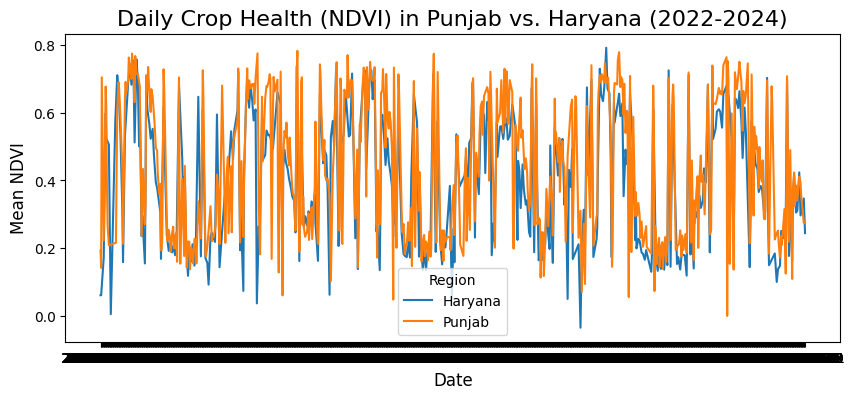

In [ ]:
plt.figure(figsize=( 10,4))
sns.lineplot(x='Date', y='mean_ndvi', data=df, hue='Region')

plt.title('Daily Crop Health (NDVI) in Punjab vs. Haryana (2022-2024)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Mean NDVI', fontsize=12)

plt.show()

 Punjab has constantly produced better crops than haryana in past three years.Every year there is a repeating pattern where there is peak and then downfall, showing the 2 cropping seasons - kharif and rabi.There are **broader peaks in march-may and september-october**.

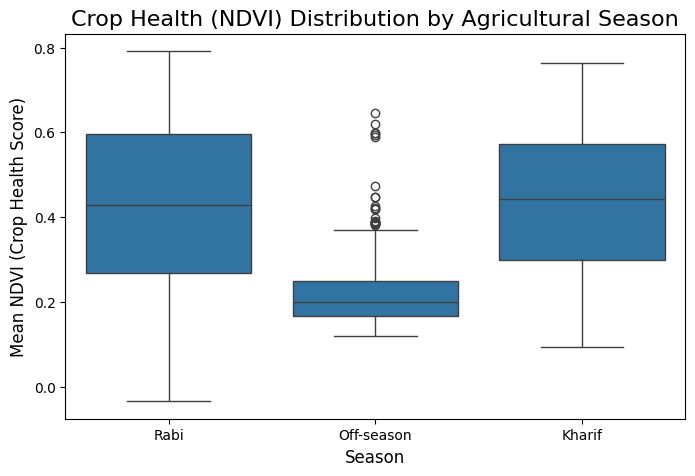

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season_Type', y='mean_ndvi')
plt.title('Crop Health (NDVI) Distribution by Agricultural Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Mean NDVI (Crop Health Score)', fontsize=12)
plt.show()

**Low produce during the off season.**

The **Kharif (monsoon season) and Rabi (winter season) boxes are both high**, indicating healthy crops.

 The **median NDVI for both is similar**, with Kharif perhaps being slightly higher on average. The Rabi box appears a bit taller, suggesting a wider range of NDVI values during that season.

 There are several dots in the** off season area which are outliers**. They may be due to small scale summer crops like vegetables.

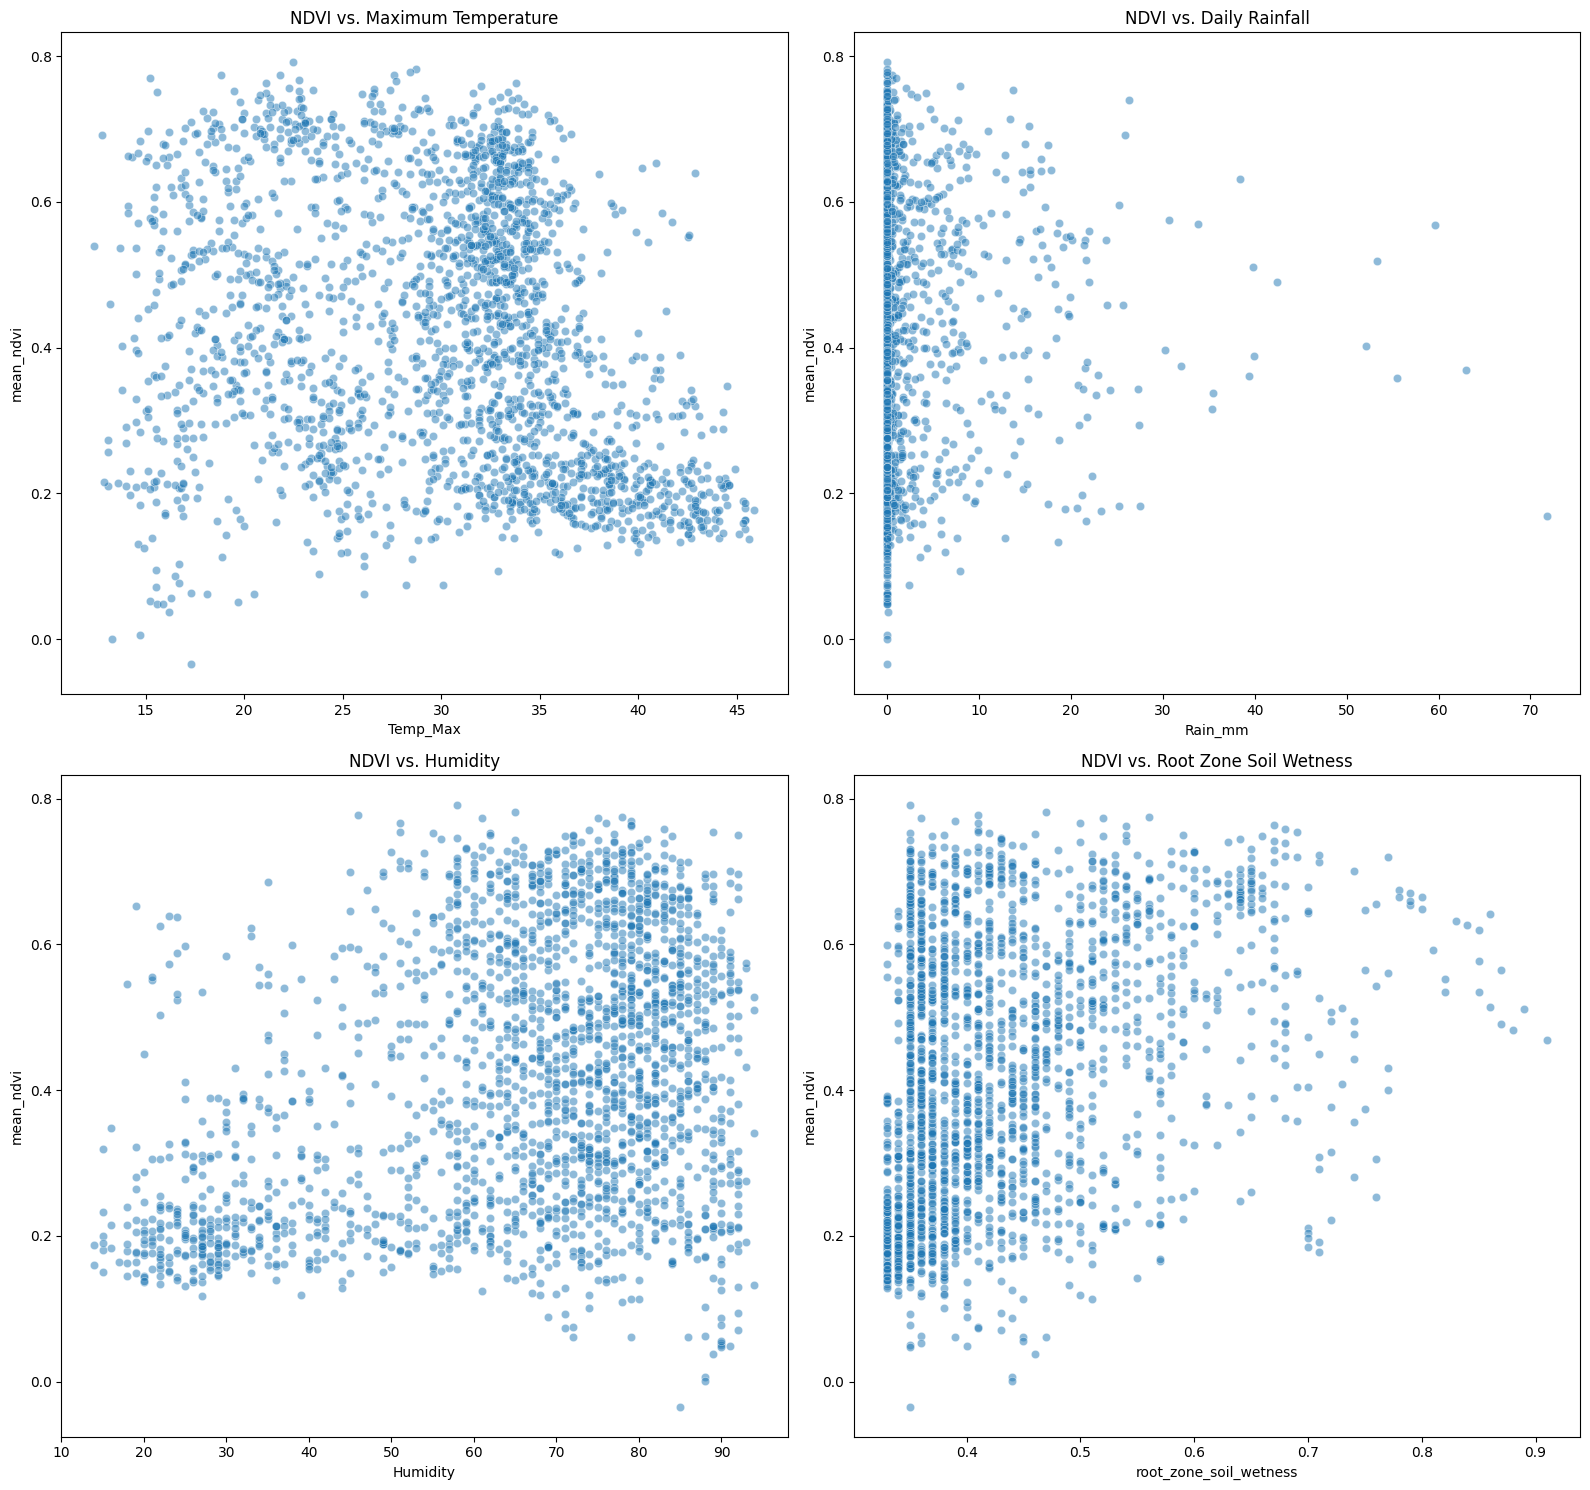

In [ ]:
fig, axes= plt.subplots(2,2,figsize=(16,15))

sns.scatterplot(data=df, x='Temp_Max', y='mean_ndvi', ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title('NDVI vs. Maximum Temperature')

# NDVI vs Daily Rainfall
sns.scatterplot(data=df, x='Rain_mm', y='mean_ndvi', ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('NDVI vs. Daily Rainfall')

# NDVI vs Humidity
sns.scatterplot(data=df, x='Humidity', y='mean_ndvi', ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title('NDVI vs. Humidity')

# NDVI vs Root Zone Soil Wetness
sns.scatterplot(data=df, x='root_zone_soil_wetness', y='mean_ndvi', ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('NDVI vs. Root Zone Soil Wetness')

plt.tight_layout()
plt.show()

The **highest** NDVI values when the temperature is **between 20°C and 35°C**. When  **higher than 40 degrees, the NDVI values are below (0.4)**.

**No relation between daily rainfall and crop growth**.

There is some **positive correlation between humidity and nvdi** as higher humidity is generally beneficial for crop health because it reduces water loss from the plants.

As **soil wetness increases, the minimum and average NDVI values also clearly increase**.

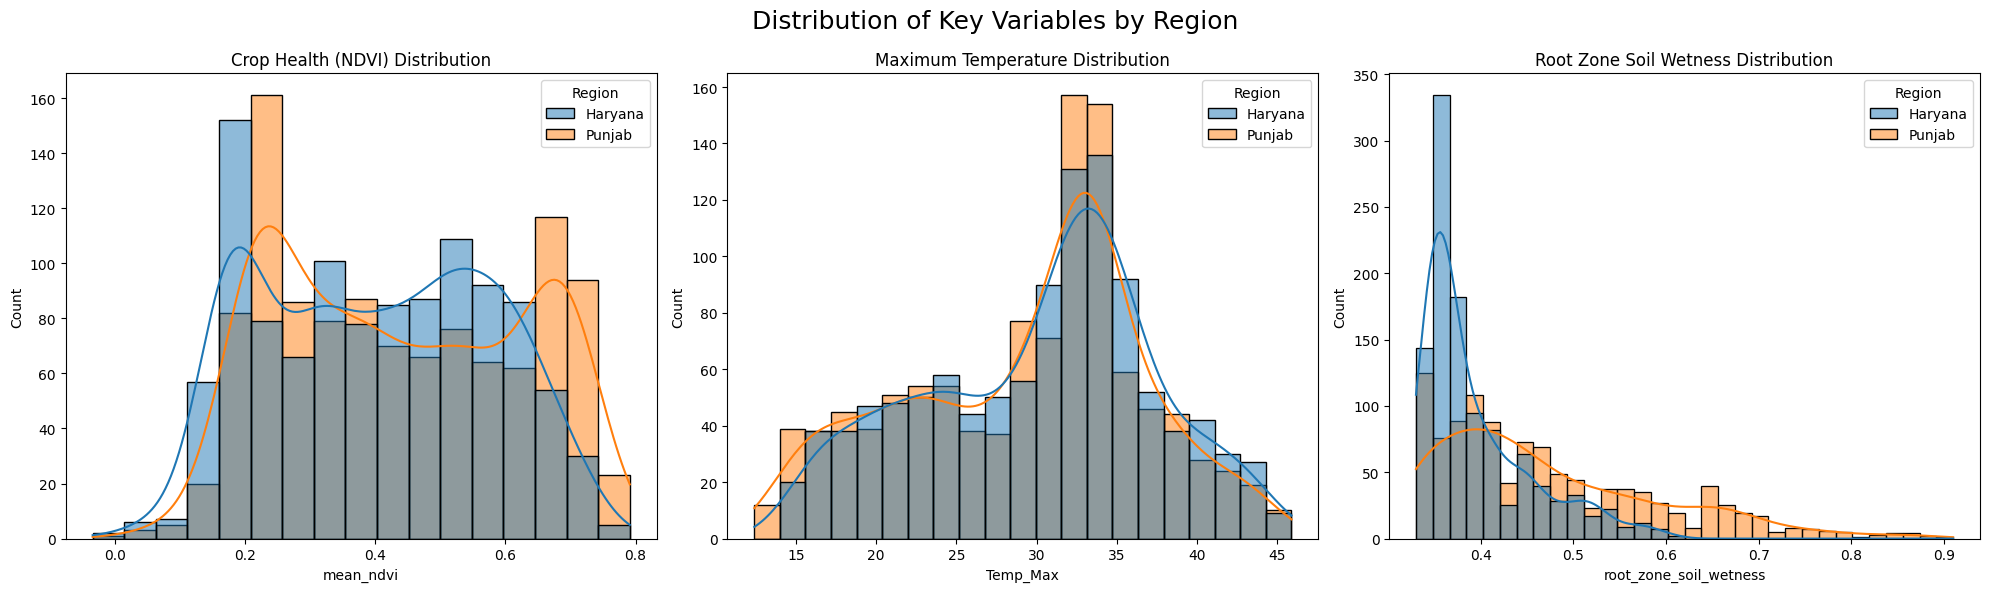

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(20, 6))
fig.suptitle('Distribution of Key Variables by Region', fontsize=18)

sns.histplot(data=df, x='mean_ndvi', hue='Region', kde=True, ax=axes[0])
axes[0].set_title('Crop Health (NDVI) Distribution')

sns.histplot(data=df, x='Temp_Max', hue='Region', kde=True, ax=axes[1])
axes[1].set_title('Maximum Temperature Distribution')

sns.histplot(data=df, x='root_zone_soil_wetness', hue='Region', kde=True, ax=axes[2])
axes[2].set_title('Root Zone Soil Wetness Distribution')

plt.tight_layout()
plt.show()

**Crop Health :** The large grey area shows that for most of the year, the range of crop health values is similar in both states.

**Maximum Temperature:** Punjab and Haryana share a very similar climate for most of the year.

**Root Zone Soil Wetness:** Punjab has a slightly higher average soil wetness.


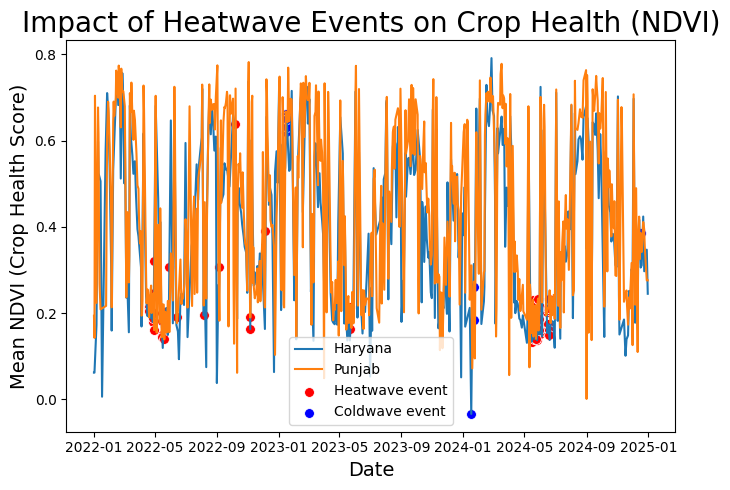

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.lineplot(data=df, x='Date',y='mean_ndvi', hue='Region',ax=ax,legend=True)
sns.scatterplot(data=df[df['Heatwave']==1],x='Date',y='mean_ndvi',color='red',ax=ax, label="Heatwave event",s=50)
sns.scatterplot(data=df[df['Coldwave']==1],x='Date',y='mean_ndvi',color='blue',ax=ax, label="Coldwave event",s=50)
ax.set_title('Impact of Heatwave Events on Crop Health (NDVI)', fontsize=20)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Mean NDVI (Crop Health Score)', fontsize=14)
plt.tight_layout()
plt.show()

Heat waves are clustered with the dips in ndvi cycle, mainly during period of **may-june w**here ndvi remains between 0.1 and 0.3. These extreme heat events are a s**tress factor that either prevents crop growth or corresponds with the period when fields are left fallow due to heatwaves**.

Blue dots are clustered with the rising peaks of ndvi mainly between jan to feb where ndvi reaches above 0.4. Coldwaves happen during the peak of Rabi (winter crop) growing season. The fact that the NDVI is high suggests that the primary winter crops (like wheat) are** tolerant to cold temperatures.**

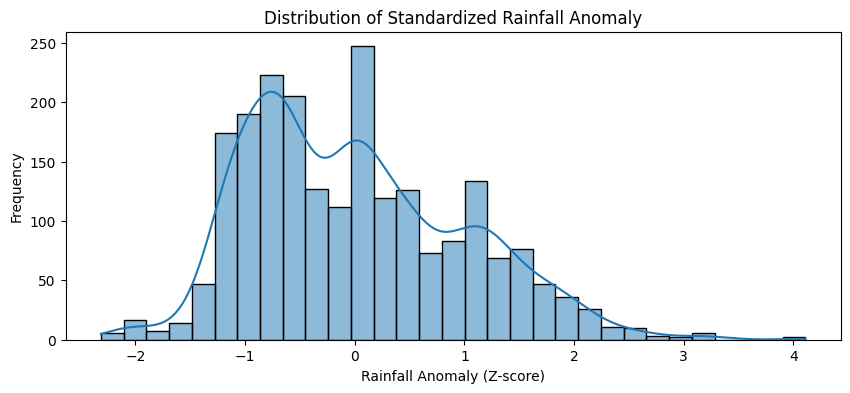

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='rainfall_anomaly', kde=True)
plt.title('Distribution of Standardized Rainfall Anomaly')
plt.xlabel('Rainfall Anomaly (Z-score)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cloud_coverage          2192 non-null   float64
 1   Date                    2192 non-null   object 
 2   day                     2192 non-null   int64  
 3   mean_ndvi               2192 non-null   float64
 4   month                   2192 non-null   int64  
 5   year                    2192 non-null   int64  
 6   Region                  2192 non-null   object 
 7   Temp_Max                2192 non-null   float64
 8   Temp_Min                2192 non-null   float64
 9   Rain_mm                 2192 non-null   float64
 10  Humidity                2192 non-null   int64  
 11  profile_soil_wetness    2192 non-null   float64
 12  root_zone_soil_wetness  2192 non-null   float64
 13  Season_Type             2192 non-null   object 
 14  14_dayRainSum           2192 non-null   

In [ ]:
df['Date']=pd.to_datetime(df['Date'])

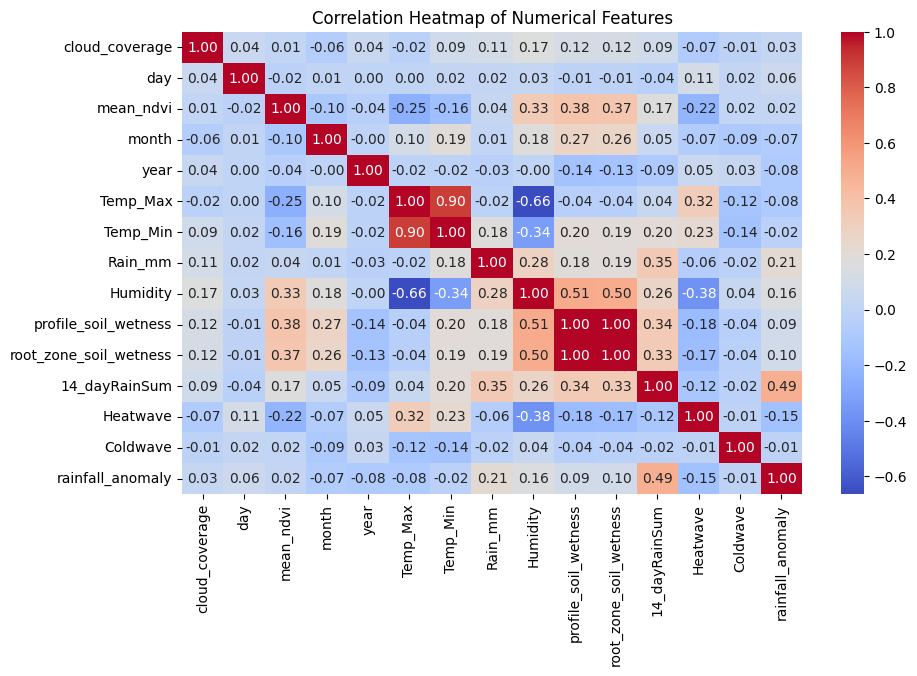

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   cloud_coverage          2192 non-null   float64       
 1   Date                    2192 non-null   datetime64[ns]
 2   day                     2192 non-null   int64         
 3   mean_ndvi               2192 non-null   float64       
 4   month                   2192 non-null   int64         
 5   year                    2192 non-null   int64         
 6   Region                  2192 non-null   object        
 7   Temp_Max                2192 non-null   float64       
 8   Temp_Min                2192 non-null   float64       
 9   Rain_mm                 2192 non-null   float64       
 10  Humidity                2192 non-null   int64         
 11  profile_soil_wetness    2192 non-null   float64       
 12  root_zone_soil_wetness  2192 non-null   float64 

In [ ]:
df1= df.copy()

In [ ]:
df1[['Region', 'Season_Type']].dtypes

,0
Region,object
Season_Type,object


In [ ]:
df1= pd.get_dummies(df1, columns=['Region', 'Season_Type'],drop_first=True)

In [ ]:
df1.head()

,cloud_coverage,Date,day,mean_ndvi,month,year,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,14_dayRainSum,Heatwave,Coldwave,rainfall_anomaly,Region_Punjab,Season_Type_Off-season,Season_Type_Rabi
0,0.000000,2022-01-01,1,0.061829,1,2022,18.1,4.2,0.0,79,0.39,0.39,0.0,0,0,0.0,False,False,True
1,0.349554,2022-01-02,1,0.061829,2,2022,20.5,7.2,0.0,86,0.45,0.45,0.0,0,0,0.0,False,False,True
2,0.000000,2022-01-03,1,0.089505,3,2022,23.8,9.9,0.0,69,0.41,0.40,0.0,0,0,0.0,False,False,True
3,0.000000,2022-01-04,1,0.117181,4,2022,36.0,20.6,0.0,27,0.36,0.36,0.0,0,0,0.0,False,False,True
4,0.000000,2022-01-05,1,0.144858,5,2022,42.5,25.8,0.0,29,0.35,0.34,0.0,0,0,0.0,False,True,False


In [ ]:
df1[['Region_Punjab', 'Season_Type_Off-season', 'Season_Type_Rabi']]=df1[['Region_Punjab', 'Season_Type_Off-season', 'Season_Type_Rabi']].astype(int)

In [ ]:
df1.head()

,cloud_coverage,Date,day,mean_ndvi,month,year,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,14_dayRainSum,Heatwave,Coldwave,rainfall_anomaly,Region_Punjab,Season_Type_Off-season,Season_Type_Rabi
0,0.000000,2022-01-01,1,0.061829,1,2022,18.1,4.2,0.0,79,0.39,0.39,0.0,0,0,0.0,0,0,1
1,0.349554,2022-01-02,1,0.061829,2,2022,20.5,7.2,0.0,86,0.45,0.45,0.0,0,0,0.0,0,0,1
2,0.000000,2022-01-03,1,0.089505,3,2022,23.8,9.9,0.0,69,0.41,0.40,0.0,0,0,0.0,0,0,1
3,0.000000,2022-01-04,1,0.117181,4,2022,36.0,20.6,0.0,27,0.36,0.36,0.0,0,0,0.0,0,0,1
4,0.000000,2022-01-05,1,0.144858,5,2022,42.5,25.8,0.0,29,0.35,0.34,0.0,0,0,0.0,0,1,0


In [ ]:
df1.shape

(2192, 19)

In [ ]:
df1_lag= df1.copy()

In [ ]:
df1_lag= df1_lag.sort_values(by=['Region_Punjab', 'Date'])

In [ ]:
df1_lag.head(8)

,cloud_coverage,Date,day,mean_ndvi,month,year,Temp_Max,Temp_Min,Rain_mm,Humidity,profile_soil_wetness,root_zone_soil_wetness,14_dayRainSum,Heatwave,Coldwave,rainfall_anomaly,Region_Punjab,Season_Type_Off-season,Season_Type_Rabi
0,0.000000,2022-01-01,1,0.061829,1,2022,18.1,4.2,0.0,79,0.39,0.39,0.0,0,0,0.0,0,0,1
1,0.349554,2022-01-02,1,0.061829,2,2022,20.5,7.2,0.0,86,0.45,0.45,0.0,0,0,0.0,0,0,1
2,0.000000,2022-01-03,1,0.089505,3,2022,23.8,9.9,0.0,69,0.41,0.40,0.0,0,0,0.0,0,0,1
3,0.000000,2022-01-04,1,0.117181,4,2022,36.0,20.6,0.0,27,0.36,0.36,0.0,0,0,0.0,0,0,1
4,0.000000,2022-01-05,1,0.144858,5,2022,42.5,25.8,0.0,29,0.35,0.34,0.0,0,0,0.0,0,1,0
5,4.883948,2022-01-06,1,0.172534,6,2022,41.0,24.7,0.0,31,0.35,0.35,0.0,0,0,0.0,0,0,0
6,0.000000,2022-01-07,1,0.314298,7,2022,32.4,25.3,0.3,79,0.41,0.43,0.0,0,0,0.0,0,0,0
7,0.000000,2022-01-08,1,0.456062,8,2022,32.2,24.4,7.4,86,0.60,0.61,0.0,0,0,0.0,0,0,0


In [ ]:
# Lag NDVI for the past 7 days
for i in range(1, 8):
    df1_lag[f'ndvi_lag_{i}'] = df1_lag.groupby('Region_Punjab')['mean_ndvi'].shift(i)


In [ ]:
for i in range(1, 4):
    df1_lag[f'temp_max_lag_{i}'] = df1_lag.groupby('Region_Punjab')['Temp_Max'].shift(i)
    df1_lag[f'soil_wetness_lag_{i}'] = df1_lag.groupby('Region_Punjab')['root_zone_soil_wetness'].shift(i)


In [ ]:
df1_lag.head(8)

,cloud_coverage,Date,day,mean_ndvi,month,year,Temp_Max,Temp_Min,Rain_mm,Humidity,...,ndvi_lag_4,ndvi_lag_5,ndvi_lag_6,ndvi_lag_7,temp_max_lag_1,soil_wetness_lag_1,temp_max_lag_2,soil_wetness_lag_2,temp_max_lag_3,soil_wetness_lag_3
0,0.000000,2022-01-01,1,0.061829,1,2022,18.1,4.2,0.0,79,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.349554,2022-01-02,1,0.061829,2,2022,20.5,7.2,0.0,86,...,NaN,NaN,NaN,NaN,18.1,0.39,NaN,NaN,NaN,NaN
2,0.000000,2022-01-03,1,0.089505,3,2022,23.8,9.9,0.0,69,...,NaN,NaN,NaN,NaN,20.5,0.45,18.1,0.39,NaN,NaN
3,0.000000,2022-01-04,1,0.117181,4,2022,36.0,20.6,0.0,27,...,NaN,NaN,NaN,NaN,23.8,0.40,20.5,0.45,18.1,0.39
4,0.000000,2022-01-05,1,0.144858,5,2022,42.5,25.8,0.0,29,...,0.061829,NaN,NaN,NaN,36.0,0.36,23.8,0.40,20.5,0.45
5,4.883948,2022-01-06,1,0.172534,6,2022,41.0,24.7,0.0,31,...,0.061829,0.061829,NaN,NaN,42.5,0.34,36.0,0.36,23.8,0.40
6,0.000000,2022-01-07,1,0.314298,7,2022,32.4,25.3,0.3,79,...,0.089505,0.061829,0.061829,NaN,41.0,0.35,42.5,0.34,36.0,0.36
7,0.000000,2022-01-08,1,0.456062,8,2022,32.2,24.4,7.4,86,...,0.117181,0.089505,0.061829,0.061829,32.4,0.43,41.0,0.35,42.5,0.34


In [ ]:
df1_lag = df1_lag.dropna()

In [ ]:
df1_lag.shape

(2178, 32)

In [ ]:
train_df= df1_lag[df1_lag['Date'].dt.year<2024]
test_df= df1_lag[df1_lag['Date'].dt.year==2024]

In [ ]:
train_df.shape

(1446, 32)

In [ ]:
test_df.shape

(732, 32)

In [ ]:
df1_lag.columns

Index(['cloud_coverage', 'Date', 'day', 'mean_ndvi', 'month', 'year',
       'Temp_Max', 'Temp_Min', 'Rain_mm', 'Humidity', 'profile_soil_wetness',
       'root_zone_soil_wetness', '14_dayRainSum', 'Heatwave', 'Coldwave',
       'rainfall_anomaly', 'Region_Punjab', 'Season_Type_Off-season',
       'Season_Type_Rabi', 'ndvi_lag_1', 'ndvi_lag_2', 'ndvi_lag_3',
       'ndvi_lag_4', 'ndvi_lag_5', 'ndvi_lag_6', 'ndvi_lag_7',
       'temp_max_lag_1', 'soil_wetness_lag_1', 'temp_max_lag_2',
       'soil_wetness_lag_2', 'temp_max_lag_3', 'soil_wetness_lag_3'],
      dtype='object')

<Axes: >

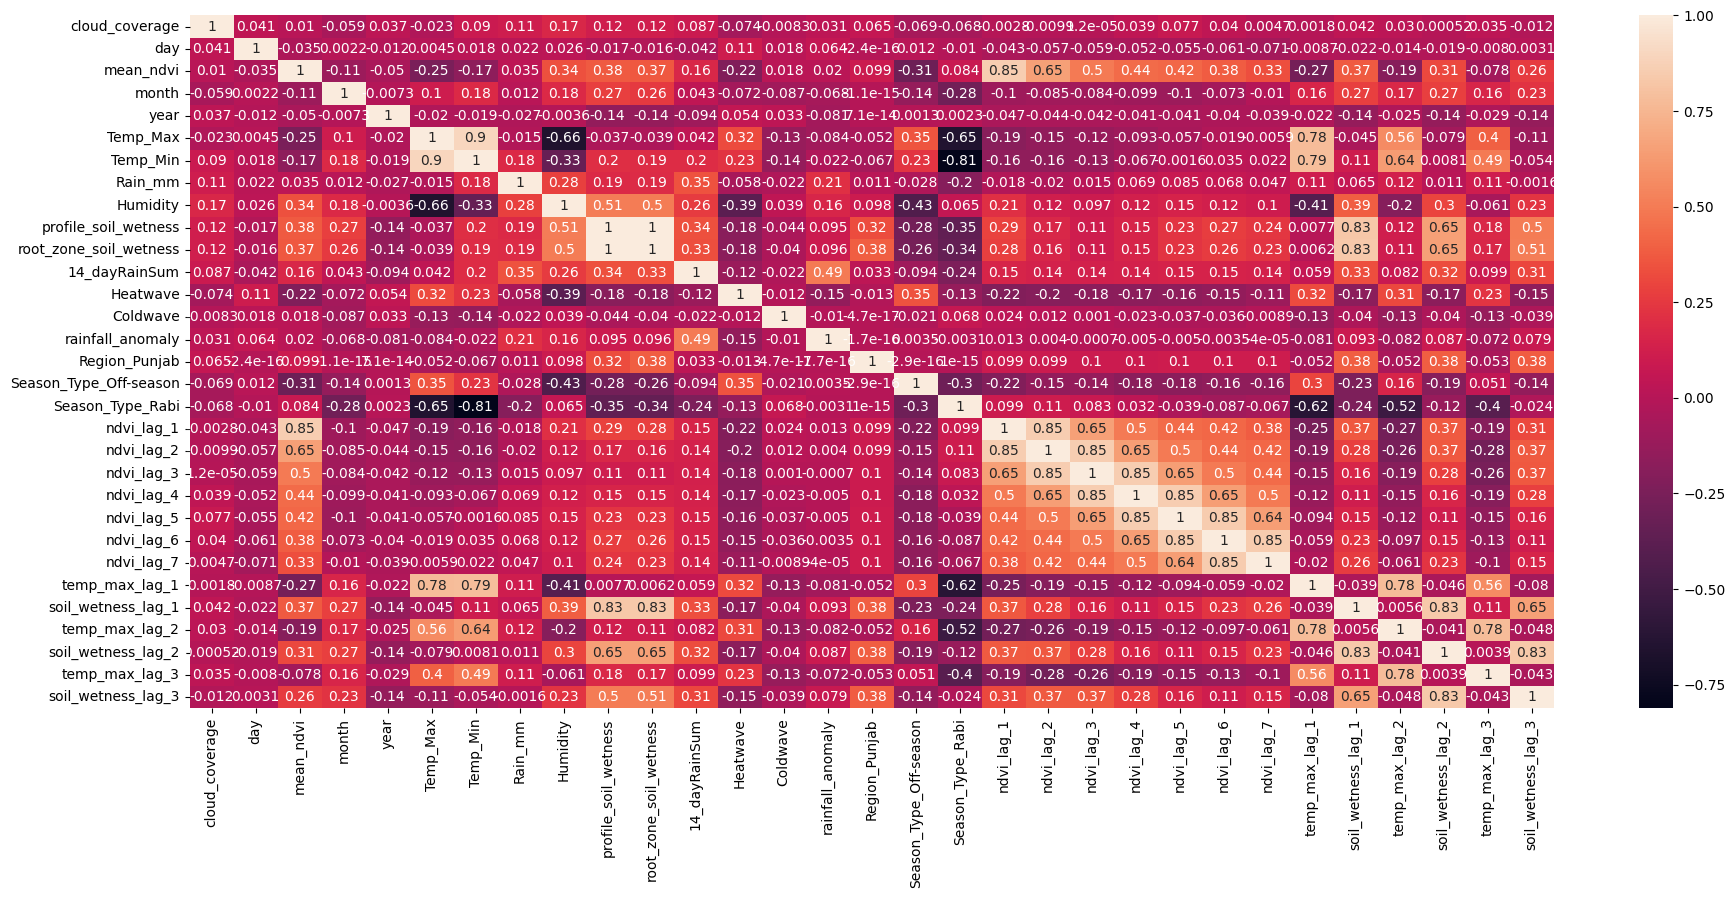

In [ ]:
numeric_df_lag= df1_lag.select_dtypes(include= np.number)
cm= numeric_df_lag.corr()
plt.figure(figsize=(22,9))
sns.heatmap(cm, annot=True)

In [ ]:
features= [col for col in df1_lag.columns if col not in ['Date', 'mean_ndvi']]


In [ ]:
import xgboost as xgb

In [ ]:
Xtrain= train_df[features]
ytrain= train_df['mean_ndvi']

Xtest= test_df[features]
ytest= test_df['mean_ndvi']

In [ ]:
Xtest.shape

(732, 30)

In [ ]:
xgmodel= xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, max_depth=3,learning_rate=0.05,early_stopping_rounds=50)

In [ ]:
xgmodel.fit(Xtrain, ytrain,
            eval_set=[(Xtest,ytest)],
            verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgmodel_pred= xgmodel.predict(Xtest)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
xgmodel_mae = mean_absolute_error(ytest, xgmodel_pred)
xgmodel_mse = mean_squared_error(ytest, xgmodel_pred)
xgmodel_rmse = np.sqrt(xgmodel_mse)
xgmodel_r2= r2_score(ytest,xgmodel_pred)

print(f"XGBoost Model Performance")
print(f"Mean Absolute Error (MAE): {xgmodel_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {xgmodel_rmse:.4f}")
print(f"R-squared (R2): {xgmodel_r2:.4f}")

XGBoost Model Performance
Mean Absolute Error (MAE): 0.0566
Root Mean Squared Error (RMSE): 0.0814
R-squared (R2): 0.8185


In [ ]:
import matplotlib.pyplot as plt



In [ ]:
test_df_sorted = test_df.sort_values(by='Date')


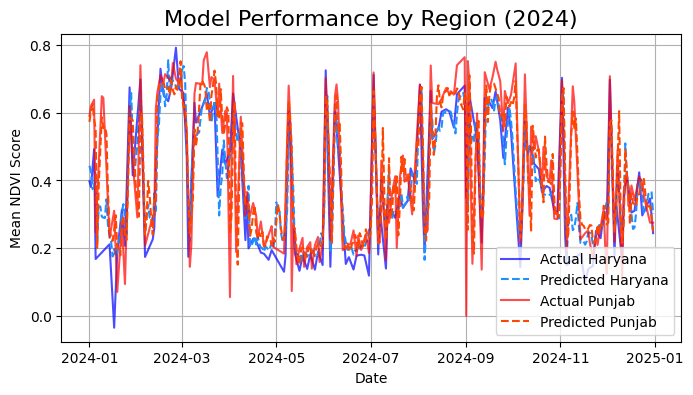

In [ ]:
haryana_test = test_df_sorted[test_df_sorted['Region_Punjab'] == 0]
punjab_test = test_df_sorted[test_df_sorted['Region_Punjab'] == 1]

haryana_preds = xgmodel.predict(haryana_test[features])
punjab_preds = xgmodel.predict(punjab_test[features])

plt.figure(figsize=(8, 4))

plt.plot(haryana_test['Date'], haryana_test['mean_ndvi'], label='Actual Haryana', color='blue', alpha=0.7)
plt.plot(haryana_test['Date'], haryana_preds, label='Predicted Haryana', color='dodgerblue', linestyle='--')

plt.plot(punjab_test['Date'], punjab_test['mean_ndvi'], label='Actual Punjab', color='red', alpha=0.7)
plt.plot(punjab_test['Date'], punjab_preds, label='Predicted Punjab', color='orangered', linestyle='--')

plt.title('Model Performance by Region (2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Mean NDVI Score')
plt.legend()
plt.grid(True)
plt.show()

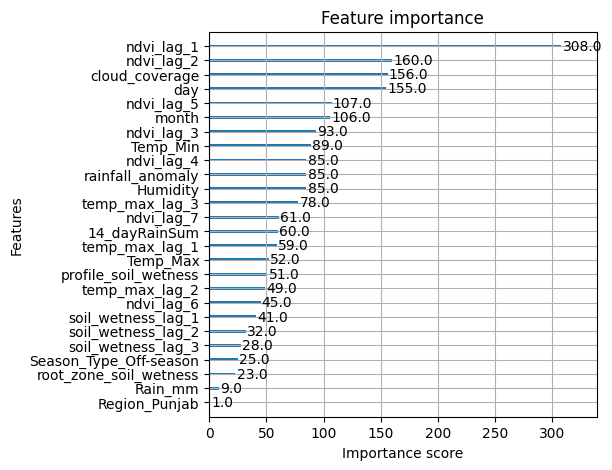

In [ ]:
import matplotlib.pyplot as plt
fig, axs= plt.subplots(figsize=(5,5))
xgb.plot_importance(xgmodel, ax=axs)
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(xgmodel,'CropStressPredictionModelForPunjabHaryana')
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

df1_sarimax = df1.set_index('Date')
X_sarimax = df1_sarimax.drop(columns=['mean_ndvi', 'Temp_Min', 'profile_soil_wetness'])
y_sarimax = df1_sarimax['mean_ndvi']

X_train_sarimax = X_sarimax[X_sarimax.index.year < 2024]
y_train_sarimax = y_sarimax[y_sarimax.index.year < 2024]
X_test_sarimax = X_sarimax[X_sarimax.index.year == 2024]
y_test_sarimax = y_sarimax[y_sarimax.index.year == 2024]

best_aic = float('inf')
best_order = None
best_model = None
print("Starting SARIMAX grid search...")
for p in range(3):
    for q in range(3):
        try:
            temp_model = sm.tsa.SARIMAX(
                endog=y_train_sarimax, exog=X_train_sarimax,
                order=(p, 1, q), seasonal_order=(1, 1, 1, 7)
            ).fit(disp=False)
            if temp_model.aic < best_aic:
                best_aic = temp_model.aic
                best_order = (p, 1, q)
                best_model = temp_model
        except:
            continue
print("Grid search complete.")
if best_model is None:
    print("No valid SARIMAX model found during grid search.")
else:
    print(f"Best Order Found: {best_order} with AIC: {best_aic:.2f}")


    predictions_sarimax = best_model.forecast(steps=len(X_test_sarimax), exog=X_test_sarimax)

    mae_sarimax = mean_absolute_error(y_test_sarimax, predictions_sarimax)
    mse_sarimax = mean_squared_error(y_test_sarimax, predictions_sarimax)
    rmse_sarimax = np.sqrt(mse_sarimax)
    r2_score_sarimax = r2_score(y_test_sarimax, predictions_sarimax)

    print(f"\n--- SARIMAX Model Performance ---")
    print(f"Mean Absolute Error (MAE): {mae_sarimax:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_sarimax:.4f}")
    print(f"R-squared (R2): {r2_score_sarimax:.4f}")

Starting SARIMAX grid search...
Grid search complete.
Best Order Found: (2, 1, 1) with AIC: -2731.77

--- SARIMAX Model Performance ---
Mean Absolute Error (MAE): 1.8854
Root Mean Squared Error (RMSE): 2.0526
R-squared (R2): -114.3508


### A classical, linear time-series model like SARIMAX is not capable of capturing the complex, non-linear relationships between weather, season, and crop health. The powerful, tree-based XGBoost model, which had a much lower MAE of ~0.05, is far superior for this task